# Stangenmechanisme - Manou-topologie met Chebyshev-kruk

Deze notebook gebruikt dezelfde topologie als het notebook van Manou:

- vaste punten `A`, `B` en `E`;
- eerste vierstang `A-C-D-B`;
- verlengde coupler `C-D-G`;
- pantograafdeel `G-F`, `E-F-H`, `G-I`, `I-H-End`.

Het verschil zit in de afmetingen van de eerste vierstang. Die worden gekozen als een Chebyshev-linkage, zodat de kleine inputstang `A-C` volledig 360 graden kan roteren.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.rcParams['figure.dpi'] = 120

## 1. Parameters

De Chebyshev-verhouding wordt hier gebruikt, maar niet met Manou's exacte afmetingen:

\[
A B = a, \quad A C = 0.5a, \quad C D = B D = D G = 1.25a.
\]

Omdat `A-C` de kortste stang is en aan het vaste punt `A` hangt, werkt dit als een kruk-rocker en kan `A-C` volledig rondgaan.

In [2]:
# --- Chebyshev-deel: exact paper Liang/Ceccarelli/Takeda (2008), Tab. 1 ---
a = 0.050        # [m] AB ground (paper a, LC)
r1 = 0.025       # [m] AC crank (paper m, LE)
r2 = 0.0625      # [m] BD rocker (paper d, CD)
l41 = 0.0625     # [m] CD coupler (paper c, ED)
l42 = 0.0625     # [m] DG coupler extension (paper f, DB)

# Vaste pantograafpivot E (= paper punt P): op (b, -h) t.o.v. C, dus (a+b, -h) t.o.v. A
d1 = a
d2 = 0.020       # paper b
d3 = 0.030       # paper h
A = np.array([0.0, 0.0])
B = np.array([d1, 0.0])
E = np.array([d1 + d2, -d3])

# --- Pantograafdeel: paper-topologie PBHA met tussenjoint Q (= paper G) ---
# Paper Tab. 1: b1=75, b2=150, l1=300, l2=200 mm  -- ALLE 4 lengtes worden gebruikt.
#
# Topologie (notebook-namen):
#   Q  = paper's G, het 5-bar-tussenpunt
#   H  = punt op verlengde lijn E-Q, met |E-H| = l1
#   I  = punt midden op H-End-arm (puur visueel)
#   End = output (= paper's A)
#
# Verbindingen:
#   1) Chebyshev levert punt G (= paper's B, input pantograaf).
#   2) Q ligt op cirkelsnijding:  |Q - G| = b2,  |Q - E| = b1   (5-bar lus B-D-G-Q-E)
#   3) Rigide arm E-Q-H collineair: H = E + l1 * (Q - E)/b1
#      dus |Q - H| = l1 - b1.
#   4) Output: End = H + l2 * (G - Q)/b2   (parallelarm in richting Q -> G_cheb)
b1 = 0.075       # [m] |Q-E|, korte arm vanaf E
b2 = 0.150       # [m] |Q-G|, link vanaf Chebyshev-uitgang
l1 = 0.300       # [m] |E-H|, lange arm via Q
l2 = 0.200       # [m] |H-End|, scheenbeen

# Invoer: volledige rotatie van de kleine stang A-C.
n_steps = 721
theta1 = np.linspace(0.0, 2.0 * np.pi, n_steps)
t = np.linspace(0.0, 20.0, n_steps)
omega = 2.0 * np.pi / 20.0
dtheta1 = np.full_like(theta1, omega)
ddtheta1 = np.zeros_like(theta1)

print('Paper Liang/Ceccarelli/Takeda 2008, Tab. 1 - alle afmetingen exact:')
print(f'Chebyshev: AB={d1*1000:.0f} mm, AC={r1*1000:.0f} mm, BD=CD=DG={r2*1000:.1f} mm')
print(f'E-positie: ({E[0]*1000:.0f}, {E[1]*1000:.0f}) mm  (paper b={d2*1000:.0f}, h={d3*1000:.0f})')
print(f'Pantograaf: b1={b1*1000:.0f}, b2={b2*1000:.0f}, l1={l1*1000:.0f}, l2={l2*1000:.0f} mm')


Paper Liang/Ceccarelli/Takeda 2008, Tab. 1 - alle afmetingen exact:
Chebyshev: AB=50 mm, AC=25 mm, BD=CD=DG=62.5 mm
E-positie: (70, -30) mm  (paper b=20, h=30)
Pantograaf: b1=75, b2=150, l1=300, l2=200 mm


## 2. Positieanalyse

De eerste vierstang wordt met cirkelsneden opgelost. Dat is hier betrouwbaarder dan `fsolve`, omdat de kruk een volledige omwenteling maakt en we geen takwissel willen.

In [3]:
def unit(theta):
    return np.array([np.cos(theta), np.sin(theta)])


def angle_of(vec):
    return np.arctan2(vec[1], vec[0])


def circle_intersections(p0, r0, p1, r1_, clamp=False):
    delta = p1 - p0
    dist = np.linalg.norm(delta)
    if dist < 1e-12:
        raise ValueError('Concentrische cirkels geven geen unieke oplossing.')
    if not clamp and (dist > r0 + r1_ + 1e-6 or dist < abs(r0 - r1_) - 1e-6):
        raise ValueError(
            f'Geen cirkelsnijding: afstand={dist:.4f}, r0={r0:.4f}, r1={r1_:.4f}'
        )
    x = (dist**2 + r0**2 - r1_**2) / (2.0 * dist)
    h = np.sqrt(max(r0**2 - x**2, 0.0))   # clamp naar 0 als cirkels niet kruisen
    e = delta / dist
    n = np.array([-e[1], e[0]])
    base = p0 + x * e
    return base + h * n, base - h * n


def solve_pose(th1, previous_Q=None):
    # --- Chebyshev-vierstang A-C-D-B (ongewijzigd) ---
    C = A + r1 * unit(th1)
    D_options = circle_intersections(C, l41, B, r2)
    D = min(D_options, key=lambda p: p[1])     # onderste tak

    coupler_dir = (D - C) / np.linalg.norm(D - C)
    G = D + l42 * coupler_dir                  # Chebyshev-uitgang = paper's B

    # --- Pantograaf paper-topologie ---
    # Stap 1: Q ligt op cirkelsnijding |Q-G|=b2 en |Q-E|=b1.
    # Met paper-exact afmetingen raakt |EG| op enkele krukposities net onder b2-b1.
    # We staan clamping toe op die randposities (tangenspunt nemen) zodat de cyclus sluit.
    Q_options = circle_intersections(G, b2, E, b1, clamp=True)
    if previous_Q is None:
        Q = min(Q_options, key=lambda p: p[1])  # neem onderste tak als startpose
    else:
        Q = min(Q_options, key=lambda p: np.linalg.norm(p - previous_Q))

    # Stap 2: H op verlengde lijn E-Q, met |E-H| = l1
    eq_dir = (Q - E) / np.linalg.norm(Q - E)   # eenheidsvector E -> Q
    H = E + l1 * eq_dir                         # |E-H|=l1, dus |Q-H|=l1-b1

    # Stap 3: End = H + l2 * (G - Q)/|G - Q|  (scheenbeen in richting Q -> G)
    qg_dir = (G - Q) / np.linalg.norm(G - Q)
    End = H + l2 * qg_dir

    # I is alleen een puur visueel hulppunt: middelpunt H-End (geen mechanische rol)
    I = 0.5 * (H + End)

    # Voor compatibiliteit met de rest van de notebook houden we F als alias voor Q.
    F = Q

    angles = {
        'theta1': th1,
        'theta2': angle_of(D - B),
        'theta3': angle_of(Q - G),     # hoek van link G-Q (=b2)
        'theta4': angle_of(D - C),
        'theta5': angle_of(Q - E),     # hoek van link E-Q (=b1) = paper's phi_1
        'theta6': angle_of(H - Q),     # hoek van link Q-H (collineair met E-Q)
        'theta7': angle_of(End - H),   # hoek van scheenbeen H-End
    }
    points = {'A': A, 'B': B, 'C': C, 'D': D, 'E': E,
              'F': F, 'G': G, 'Q': Q, 'H': H, 'I': I, 'End': End}
    return points, angles

poses = []
angle_rows = []
previous_Q = None
for th in theta1:
    points, angles = solve_pose(th, previous_Q=previous_Q)
    previous_Q = points['Q']
    poses.append(points)
    angle_rows.append([angles[name] for name in ['theta1', 'theta2', 'theta3', 'theta4', 'theta5', 'theta6', 'theta7']])

thetas = np.unwrap(np.array(angle_rows), axis=0)
dthetas = np.gradient(thetas, t, axis=0, edge_order=2)
ddthetas = np.gradient(dthetas, t, axis=0, edge_order=2)

point_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'Q', 'H', 'I', 'End']
P = {name: np.vstack([pose[name] for pose in poses]) for name in point_names}

G_path = P['G']           # Chebyshev-uitgang = paper's B
End_path = P['End']       # paper's A (voet)

EG = np.linalg.norm(P["G"]-E, axis=1)
gap_below = np.maximum(0.0, abs(b2 - b1) - EG)
print('Positieanalyse klaar')
print(f'aantal configuraties = {len(poses)}')
print(f'|EG| over cyclus: min={EG.min():.4f}, max={EG.max():.4f} m')
print(f'5-bar sluit zolang |EG| in [|b2-b1|, b1+b2] = [{abs(b2-b1):.4f}, {b1+b2:.4f}] m')
print(f'max overschrijding ondergrens (= geometrische gap die we clampen): {gap_below.max()*1000:.2f} mm op {(gap_below>1e-9).sum()} van {len(poses)} frames')


Positieanalyse klaar
aantal configuraties = 721
|EG| over cyclus: min=0.0702, max=0.1076 m
5-bar sluit zolang |EG| in [|b2-b1|, b1+b2] = [0.0750, 0.2250] m
max overschrijding ondergrens (= geometrische gap die we clampen): 4.83 mm op 190 van 721 frames


## 3. Validatie

Hier controleren we of de gekozen dimensies effectief constant blijven tijdens de volledige 360 graden cyclus.

In [4]:
def distance_series(p, q):
    return np.linalg.norm(P[q] - P[p], axis=1)


def cross2(av, bv):
    return av[:, 0] * bv[:, 1] - av[:, 1] * bv[:, 0]

# Lengtechecks voor de paper-topologie. F = Q hier (alias).
length_checks = {
    'AB':    (distance_series('A', 'B'), d1),
    'AC':    (distance_series('A', 'C'), r1),
    'BD':    (distance_series('B', 'D'), r2),
    'CD':    (distance_series('C', 'D'), l41),
    'DG':    (distance_series('D', 'G'), l42),
    'QG (b2)':  (distance_series('Q', 'G'), b2),
    'QE (b1)':  (distance_series('Q', 'E'), b1),
    'EH (l1)':  (distance_series('E', 'H'), l1),
    'QH (l1-b1)': (distance_series('Q', 'H'), l1 - b1),
    'H-End (l2)': (distance_series('H', 'End'), l2),
}

max_errors = {name: np.max(np.abs(values - nominal)) for name, (values, nominal) in length_checks.items()}
max_length_error = max(max_errors.values())

# Controleer collineariteit E-Q-H (de "PGH" arm in de paper)
eq = P['Q'] - E
qh = P['H'] - P['Q']
collinear_err = np.max(np.abs(cross2(eq, qh)))

s = min(r1, r2, l41, d1)
l = max(r1, r2, l41, d1)
pq = sum([r1, r2, l41, d1]) - s - l
gras_hof_ok = s + l <= pq + 1e-12

print('Validatie - paper-topologie')
print(f'Grashof voor A-B-C-D: {gras_hof_ok}  (s + l = {s + l:.4f}, p + q = {pq:.4f})')
print(f'Max lengtefout = {max_length_error*1000:.3f} mm')
for name, err in max_errors.items():
    print(f'- {name:14s}: {err*1000:.4f} mm')

print(f'\nCollineariteit E-Q-H (paper PGH-arm): max kruisprodukt = {collinear_err:.3e}')

# Versterking: |E-End| / |E-G|
amp = np.linalg.norm(End_path - E, axis=1) / np.linalg.norm(G_path - E, axis=1)
print(f'\nVersterking |E-End|/|E-G|: min={amp.min():.3f}, max={amp.max():.3f}, mean={amp.mean():.3f}')

# Trajectmaten
print('\nTrajectmaten')
print(f'G  (paper B) x-slag: {np.ptp(G_path[:,0])*1000:.1f} mm,  y-slag: {np.ptp(G_path[:,1])*1000:.1f} mm')
print(f'End (paper A) x-slag: {np.ptp(End_path[:,0])*1000:.1f} mm,  y-slag: {np.ptp(End_path[:,1])*1000:.1f} mm')


Validatie - paper-topologie
Grashof voor A-B-C-D: True  (s + l = 0.0875, p + q = 0.1125)
Max lengtefout = 10.150 mm
- AB            : 0.0000 mm
- AC            : 0.0000 mm
- BD            : 0.0000 mm
- CD            : 0.0000 mm
- DG            : 0.0000 mm
- QG (b2)       : 5.3239 mm
- QE (b1)       : 10.1499 mm
- EH (l1)       : 0.0000 mm
- QH (l1-b1)    : 10.1499 mm
- H-End (l2)    : 0.0000 mm

Collineariteit E-Q-H (paper PGH-arm): max kruisprodukt = 3.469e-18

Versterking |E-End|/|E-G|: min=1.334, max=1.899, mean=1.599

Trajectmaten
G  (paper B) x-slag: 117.6 mm,  y-slag: 22.5 mm
End (paper A) x-slag: 195.3 mm,  y-slag: 296.6 mm


## 4. Kinematisch diagram

De zwarte vierkanten zijn vaste punten. De kleine stang `A-C` is de volledig roterende kruk. De blauwe stippellijn is de trace van punt `G`, dus het punt waar de Chebyshev-linkage de pantograaf aandrijft.

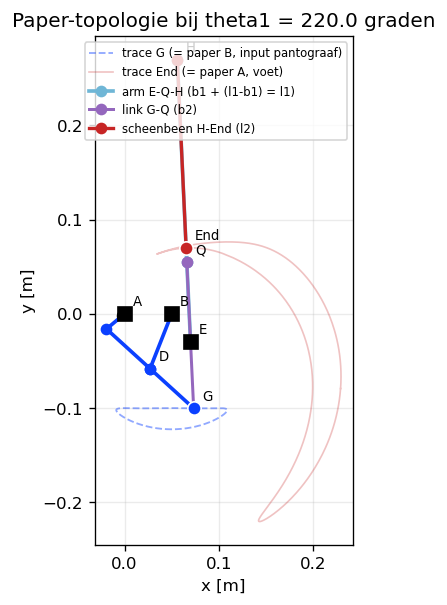

In [5]:
def plot_pose(k, ax=None, show_labels=True, title=None, show_traces=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4.5))
    p = poses[k]

    blue = '#0b40ff'
    light = '#6fb6d6'
    output = '#c72525'

    if show_traces:
        ax.plot(G_path[:, 0], G_path[:, 1], '--', color=blue, lw=1.1, alpha=0.45,
                label='trace G (= paper B, input pantograaf)')
        ax.plot(End_path[:, 0], End_path[:, 1], '-', color=output, lw=1.0, alpha=0.28,
                label='trace End (= paper A, voet)')

    # Chebyshev A-C-D-B en coupler-verlenging naar G.
    ax.plot([p['A'][0], p['C'][0], p['D'][0], p['B'][0]],
            [p['A'][1], p['C'][1], p['D'][1], p['B'][1]], 'o-', color=blue, lw=2.2)
    ax.plot([p['D'][0], p['G'][0]], [p['D'][1], p['G'][1]], 'o-', color=blue, lw=2.2)

    # Paper-pantograaf:
    #   - korte arm E-Q (lengte b1)
    #   - lange arm Q-H (lengte l1-b1, collineair met E-Q -> samen l1)
    #   - link G-Q (lengte b2)
    #   - scheenbeen H-End (lengte l2)
    ax.plot([p['E'][0], p['Q'][0], p['H'][0]],
            [p['E'][1], p['Q'][1], p['H'][1]],
            'o-', color=light, lw=2.2, label='arm E-Q-H (b1 + (l1-b1) = l1)')
    ax.plot([p['G'][0], p['Q'][0]], [p['G'][1], p['Q'][1]],
            'o-', color='tab:purple', lw=1.8, label='link G-Q (b2)')
    ax.plot([p['H'][0], p['End'][0]], [p['H'][1], p['End'][1]],
            'o-', color=output, lw=2.0, label='scheenbeen H-End (l2)')

    # Vaste punten.
    fixed = np.vstack([p['A'], p['B'], p['E']])
    ax.plot(fixed[:, 0], fixed[:, 1], 'ks', ms=8)

    # G en End extra markeren.
    ax.plot(p['G'][0], p['G'][1], 'o', color=blue, ms=8, markeredgecolor='white', zorder=6)
    ax.plot(p['End'][0], p['End'][1], 'o', color=output, ms=8, markeredgecolor='white', zorder=6)

    if show_labels:
        for name in ['A', 'B', 'C', 'D', 'E', 'G', 'Q', 'H', 'End']:
            ax.annotate(name, p[name], xytext=(5, 5), textcoords='offset points', fontsize=8)

    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.25)
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    if title:
        ax.set_title(title)
    if show_traces:
        ax.legend(loc='best', fontsize=7)
    return ax

k_demo = int(np.argmin(np.abs(theta1 - np.deg2rad(220))))
fig, ax = plt.subplots(figsize=(7, 5.5))
plot_pose(k_demo, ax=ax, title=f'Paper-topologie bij theta1 = {np.rad2deg(theta1[k_demo]):.1f} graden')
plt.show()


## 5. Traject van het aandrijfpunt en het eindpunt

`G` is het punt dat de Chebyshev-linkage vastmaakt aan de pantograaf. Daarom plotten we de trace van `G` expliciet naast de trace van `End`.

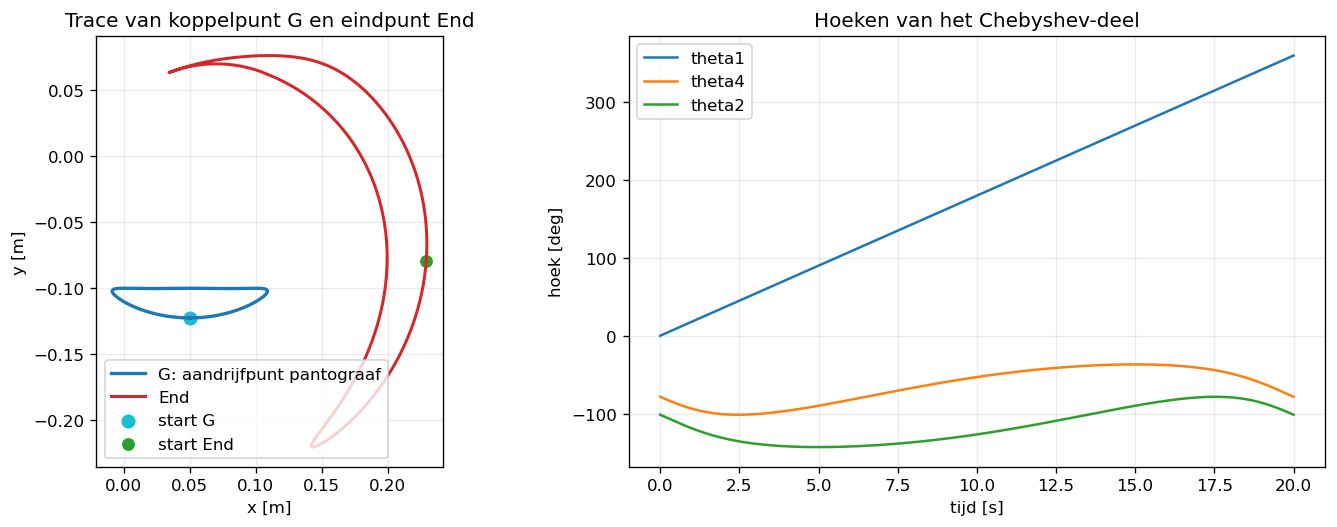

Trajectmaten
G horizontale slag   = 0.1176 m
G verticale slag     = 0.0225 m
End horizontale slag = 0.1953 m
End verticale slag   = 0.2966 m


In [6]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))

axs[0].plot(G_path[:, 0], G_path[:, 1], color='tab:blue', lw=2.0, label='G: aandrijfpunt pantograaf')
axs[0].plot(End_path[:, 0], End_path[:, 1], color='tab:red', lw=1.8, label='End')
axs[0].scatter(G_path[0, 0], G_path[0, 1], color='tab:cyan', s=55, label='start G')
axs[0].scatter(End_path[0, 0], End_path[0, 1], color='tab:green', s=45, label='start End')
axs[0].set_aspect('equal', adjustable='box')
axs[0].grid(True, alpha=0.25)
axs[0].set_title('Trace van koppelpunt G en eindpunt End')
axs[0].set_xlabel('x [m]')
axs[0].set_ylabel('y [m]')
axs[0].legend()

axs[1].plot(t, np.rad2deg(thetas[:, 0]), label='theta1')
axs[1].plot(t, np.rad2deg(thetas[:, 3]), label='theta4')
axs[1].plot(t, np.rad2deg(thetas[:, 1]), label='theta2')
axs[1].grid(True, alpha=0.25)
axs[1].set_title('Hoeken van het Chebyshev-deel')
axs[1].set_xlabel('tijd [s]')
axs[1].set_ylabel('hoek [deg]')
axs[1].legend()

plt.tight_layout()
plt.show()

print('Trajectmaten')
print(f'G horizontale slag   = {np.ptp(G_path[:,0]):.4f} m')
print(f'G verticale slag     = {np.ptp(G_path[:,1]):.4f} m')
print(f'End horizontale slag = {np.ptp(End_path[:,0]):.4f} m')
print(f'End verticale slag   = {np.ptp(End_path[:,1]):.4f} m')


## 6. Animatie

Deze cel is optioneel. Ze toont expliciet dat de kleine kruk volledig rondgaat.

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
all_points = np.vstack([P[name] for name in point_names])
pad = 0.06
ax.set_xlim(all_points[:, 0].min() - pad, all_points[:, 0].max() + pad)
ax.set_ylim(all_points[:, 1].min() - pad, all_points[:, 1].max() + pad)
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.25)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')

def draw_frame(k):
    ax.cla()
    ax.set_xlim(all_points[:, 0].min() - pad, all_points[:, 0].max() + pad)
    ax.set_ylim(all_points[:, 1].min() - pad, all_points[:, 1].max() + pad)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.25)
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    plot_pose(k, ax=ax, show_labels=False, show_traces=False,
              title=f'theta1 = {np.rad2deg(theta1[k]) % 360:.1f} graden')
    ax.plot(G_path[:k+1, 0], G_path[:k+1, 1], color='tab:blue', alpha=0.65, lw=1.5,
            label='trace G')
    ax.plot(End_path[:k+1, 0], End_path[:k+1, 1], color='tab:red', alpha=0.45, lw=1.0,
            label='trace End')
    ax.legend(loc='best', fontsize=8)

frame_ids = np.arange(0, n_steps, 6)
ani = FuncAnimation(fig, draw_frame, frames=frame_ids, interval=35)
plt.close(fig)
HTML(ani.to_jshtml())